In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Define the path to the DAiSEE.zip file in Google Drive
# Users can change this path if their file is located elsewhere in their Drive
DAISEE_ZIP_PATH = '/content/drive/MyDrive/DAiSEE.zip'

# Unzip the file to the content directory
!unzip {DAISEE_ZIP_PATH} -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/DAiSEE/DataSet/Train/210060/2100601052/2100601052.avi  
  inflating: /content/__MACOSX/DAiSEE/DataSet/Train/210060/2100601052/._2100601052.avi  
  inflating: /content/DAiSEE/DataSet/Train/210060/2100601064/2100601064.avi  
  inflating: /content/__MACOSX/DAiSEE/DataSet/Train/210060/2100601064/._2100601064.avi  
  inflating: /content/DAiSEE/DataSet/Train/210060/2100602043/2100602043.avi  
  inflating: /content/__MACOSX/DAiSEE/DataSet/Train/210060/2100602043/._2100602043.avi  
  inflating: /content/DAiSEE/DataSet/Train/210060/2100602044/2100602044.avi  
  inflating: /content/__MACOSX/DAiSEE/DataSet/Train/210060/2100602044/._2100602044.avi  
  inflating: /content/DAiSEE/DataSet/Train/210060/2100601063/2100601063.avi  
  inflating: /content/__MACOSX/DAiSEE/DataSet/Train/210060/2100601063/._2100601063.avi  
  inflating: /content/DAiSEE/DataSet/Train/210060/2100602027/2100602027.avi  
  inflating: /content/__MACOSX/DAiSE

In [3]:
import urllib.request
import os

# URL to download the haarcascade_frontalface_default.xml file
HAARCASCADE_URL = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml'
HAARCASCADE_FILENAME = 'haarcascade_frontalface_default.xml'

# Download the file if it doesn't exist
if not os.path.exists(HAARCASCADE_FILENAME):
    print(f"Downloading {HAARCASCADE_FILENAME}...")
    urllib.request.urlretrieve(HAARCASCADE_URL, HAARCASCADE_FILENAME)
    print(f"Successfully downloaded {HAARCASCADE_FILENAME}")
else:
    print(f"{HAARCASCADE_FILENAME} already exists.")

Successfully downloaded haarcascade_frontalface_default.xml


In [4]:
import cv2
import pandas as pd
import os
import shutil

# --- Configuration for Frame Extraction ---
# Define paths
base_video_dir = '/content/DAiSEE/DataSet'
output_frames_base_dir = '/content/DAiSEE_Faces_Binary' # Changed output to binary-specific directory
labels_dir = '/content/DAiSEE/Labels'

# Define the path for the face cascade XML file
# Using os.path.join(os.getcwd(), ...) for absolute path robustness
face_cascade_path = os.path.join(os.getcwd(), 'haarcascade_frontalface_default.xml')

# Load the face cascade classifier
face_cascade = cv2.CascadeClassifier(face_cascade_path)

# Check if cascade loaded successfully
if face_cascade.empty():
    print(f"Error: Failed to load face cascade from {os.path.abspath(face_cascade_path)}. ")
    print("Please ensure 'haarcascade_frontalface_default.xml' exists in the current directory and is valid.")
    raise RuntimeError("Face cascade classifier could not be loaded.")
else:
    print(f"Successfully loaded face cascade from: {os.path.abspath(face_cascade_path)}")

# Define target label column from your CSVs (this will be our newly created binary label)
TARGET_LABEL_COLUMN = 'BinaryEngagement' # New column name for binary label
FRAMES_PER_VIDEO = 5 # Number of frames to extract from each video

# Create base output directory for faces
os.makedirs(output_frames_base_dir, exist_ok=True)

# Helper function to determine binary engagement label
def get_binary_engagement_label(row):
    engagement = row.get('Engagement', 0)
    boredom = row.get('Boredom', 0)
    confusion = row.get('Confusion', 0)
    frustration = row.get('Frustration', 0)

    # Not Engaged conditions:
    # 1. Low engagement (0 or 1)
    # 2. OR presence of significant negative emotion (Boredom, Confusion, Frustration >= 2)
    if engagement <= 1 or boredom >= 2 or confusion >= 2 or frustration >= 2:
        return '0' # Not Engaged
    # Engaged conditions:
    # 1. High engagement (2 or 3) AND
    # 2. Absence of significant negative emotions (Boredom, Confusion, Frustration < 2)
    elif engagement >= 2 and boredom <= 1 and confusion <= 1 and frustration <= 1:
        return '1' # Engaged
    else:
        # Fallback for ambiguous cases, though the above rules should cover most
        return '0' # Default to Not Engaged for safety

def extract_and_organize_faces(label_df, video_base_path, output_base_path, set_name, label_column, frames_per_video, face_cascade):
    print(f"Processing {set_name} set...")
    total_videos = len(label_df)
    processed_videos = 0
    skipped_videos = 0
    no_face_detected_frames = 0

    # Clean up previous extractions for this set if they exist
    set_output_dir = os.path.join(output_base_path, set_name)
    if os.path.exists(set_output_dir):
        shutil.rmtree(set_output_dir)
    os.makedirs(set_output_dir)

    # Create binary class subdirectories (0 for Not Engaged, 1 for Engaged)
    os.makedirs(os.path.join(set_output_dir, '0'), exist_ok=True)
    os.makedirs(os.path.join(set_output_dir, '1'), exist_ok=True)

    for index, row in label_df.iterrows():
        # Get the full ClipID from the DataFrame, e.g., '2100601052.avi'
        full_clip_id_with_ext = str(row['ClipID'])
        label_value = str(row[label_column]) # Use the new binary label

        # Remove extension to get the folder name for the clip, e.g., '2100601052'
        clip_folder_name = os.path.splitext(full_clip_id_with_ext)[0]

        # Infer SubjectID from clip_folder_name (assuming first 6 digits for DAiSEE structure)
        if len(clip_folder_name) >= 6:
            subject_id = clip_folder_name[:6]
        else:
            print(f"Warning: ClipID '{full_clip_id_with_ext}' is too short to extract SubjectID. Skipping video.")
            skipped_videos += 1
            continue

        # Construct the actual video file path
        # Example: /content/DAiSEE/DataSet/Train/SubjectID/ClipFolder_Name/FullClipID_With_Ext
        current_video_path = os.path.join(base_video_dir, set_name, subject_id, clip_folder_name, full_clip_id_with_ext)

        if not os.path.exists(current_video_path):
            print(f"Video file not found for ClipID: {full_clip_id_with_ext} at {current_video_path}. Skipping.")
            skipped_videos += 1
            continue

        # Output directory for faces will be DAiSEE_Faces_Binary/{Train/Validation/Test}/{0 or 1}
        output_label_dir = os.path.join(set_output_dir, label_value)

        cap = cv2.VideoCapture(current_video_path)
        if not cap.isOpened():
            print(f"Error: Could not open video {current_video_path}. Skipping.")
            skipped_videos += 1
            cap.release()
            continue

        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if frame_count == 0:
            print(f"Video {current_video_path} has 0 frames. Skipping.")
            skipped_videos += 1
            cap.release()
            continue

        # Extract frames evenly spaced throughout the video
        frame_indices = [int(i * frame_count / (frames_per_video + 1)) for i in range(1, frames_per_video + 1)]

        extracted_faces_count = 0
        for i, idx in enumerate(frame_indices):
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                faces = face_cascade.detectMultiScale(gray, 1.3, 5)

                if len(faces) > 0:
                    # Sort faces by size (area) and pick the largest one
                    faces = sorted(faces, key=lambda x: x[2] * x[3], reverse=True)
                    (x, y, w, h) = faces[0]

                    # Expand the bounding box slightly
                    padding = int(0.2 * max(w, h)) # 20% padding
                    x_start = max(0, x - padding)
                    y_start = max(0, y - padding)
                    x_end = min(frame.shape[1], x + w + padding)
                    y_end = min(frame.shape[0], y + h + padding)

                    face_crop = frame[y_start:y_end, x_start:x_end]

                    # Use clip_folder_name for cleaner frame filenames
                    face_filename = os.path.join(output_label_dir, f"{clip_folder_name}_face_{idx:05d}.jpg")
                    cv2.imwrite(face_filename, face_crop)
                    extracted_faces_count += 1
                else:
                    no_face_detected_frames += 1
            else:
                pass # Suppress frequent warnings for brevity

        cap.release()
        processed_videos += 1
        if processed_videos % 100 == 0:
            print(f"Processed {processed_videos}/{total_videos} videos in {set_name} set.")

    print(f"Finished processing {set_name} set. Processed {processed_videos} videos, skipped {skipped_videos}, frames with no faces: {no_face_detected_frames}.")

# Load labels
print("Loading labels...")
train_labels_df = pd.read_csv(os.path.join(labels_dir, 'TrainLabels.csv'))
val_labels_df = pd.read_csv(os.path.join(labels_dir, 'ValidationLabels.csv'))
test_labels_df = pd.read_csv(os.path.join(labels_dir, 'TestLabels.csv')) # Load test labels

# --- DEBUG: Print columns to verify presence of 'Frustration' ---
print(f"TrainLabels.csv columns: {train_labels_df.columns.tolist()}")
print(f"ValidationLabels.csv columns: {val_labels_df.columns.tolist()}")
print(f"TestLabels.csv columns: {test_labels_df.columns.tolist()}")
# -----------------------------------------------------------------

# Apply the binary engagement logic to each dataframe
print("Applying new binary engagement classification logic...")
train_labels_df['BinaryEngagement'] = train_labels_df.apply(get_binary_engagement_label, axis=1)
val_labels_df['BinaryEngagement'] = val_labels_df.apply(get_binary_engagement_label, axis=1)
test_labels_df['BinaryEngagement'] = test_labels_df.apply(get_binary_engagement_label, axis=1)

# Perform face extraction using the newly calculated binary engagement label
extract_and_organize_faces(train_labels_df, base_video_dir, output_frames_base_dir, 'Train', TARGET_LABEL_COLUMN, FRAMES_PER_VIDEO, face_cascade)
extract_and_organize_faces(val_labels_df, base_video_dir, output_frames_base_dir, 'Validation', TARGET_LABEL_COLUMN, FRAMES_PER_VIDEO, face_cascade)
extract_and_organize_faces(test_labels_df, base_video_dir, output_frames_base_dir, 'Test', TARGET_LABEL_COLUMN, FRAMES_PER_VIDEO, face_cascade) # Extract test faces

print(f"All faces extracted and organized to: {output_frames_base_dir}")

Successfully loaded face cascade from: /content/haarcascade_frontalface_default.xml
Loading labels...
TrainLabels.csv columns: ['ClipID', 'Boredom', 'Engagement', 'Confusion', 'Frustration ']
ValidationLabels.csv columns: ['ClipID', 'Boredom', 'Engagement', 'Confusion', 'Frustration ']
TestLabels.csv columns: ['ClipID', 'Boredom', 'Engagement', 'Confusion', 'Frustration ']
Applying new binary engagement classification logic...
Processing Train set...
Processed 100/5358 videos in Train set.
Processed 200/5358 videos in Train set.
Processed 300/5358 videos in Train set.
Processed 400/5358 videos in Train set.
Processed 500/5358 videos in Train set.
Processed 600/5358 videos in Train set.
Processed 700/5358 videos in Train set.
Processed 800/5358 videos in Train set.
Processed 900/5358 videos in Train set.
Processed 1000/5358 videos in Train set.
Processed 1100/5358 videos in Train set.
Processed 1200/5358 videos in Train set.
Processed 1300/5358 videos in Train set.
Processed 1400/5358 v

In [5]:
from torch.utils.data import Dataset
from PIL import Image # Import Image for loading images in the custom Dataset
import re # Import re for regex operations

class SingleFrameImageDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples # List of (image_path, label_idx) tuples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Helper function to get one frame per video ID from an ImageFolder dataset
def get_one_frame_per_video_samples(image_folder_dataset):
    filtered_samples = []
    video_ids_processed = set()

    for path, class_idx in image_folder_dataset.samples:
        # Extract video ID from filename. Example: 2100601052_face_00001.jpg -> 2100601052
        filename = os.path.basename(path)
        # Assuming filename format is {ClipID}_face_{frame_idx}.jpg
        match = re.match(r'(.+)_face_\d{5}\.jpg', filename)
        if match:
            video_id = match.group(1)
        else:
            # Fallback if filename format doesn't match, or use the full filename as ID
            video_id = filename.split('.')[0] # Fallback to filename without extension

        if video_id not in video_ids_processed:
            filtered_samples.append((path, class_idx))
            video_ids_processed.add(video_id)
    return filtered_samples

print("SingleFrameImageDataset class and get_one_frame_per_video_samples helper function defined.")

SingleFrameImageDataset class and get_one_frame_per_video_samples helper function defined.


In [6]:
import shutil
import os

# Define the source directory for the binary faces
source_binary_faces_dir = '/content/DAiSEE_Faces_Binary'
# Define the target directory in Google Drive
target_drive_dir = '/content/drive/MyDrive/DAiSEE_Processed_Faces_Binary'

print(f"Saving binary processed faces from {source_binary_faces_dir} to Google Drive at {target_drive_dir}...")

# Check if the target directory already exists in Drive and remove it to ensure a fresh copy
if os.path.exists(target_drive_dir):
    print(f"Removing existing directory in Drive: {target_drive_dir}")
    shutil.rmtree(target_drive_dir)

# Copy the entire directory to Google Drive
shutil.copytree(source_binary_faces_dir, target_drive_dir)

print("Binary processed faces successfully saved to Google Drive!")
print(f"You can find them at: {target_drive_dir}")

Saving binary processed faces from /content/DAiSEE_Faces_Binary to Google Drive at /content/drive/MyDrive/DAiSEE_Processed_Faces_Binary...
Removing existing directory in Drive: /content/drive/MyDrive/DAiSEE_Processed_Faces_Binary
Binary processed faces successfully saved to Google Drive!
You can find them at: /content/drive/MyDrive/DAiSEE_Processed_Faces_Binary


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os
import copy
import collections # Import collections for Counter

# --- Configuration ---
# You might need to adjust these paths based on your DAiSEE dataset structure
# The unzipping likely put the data in /content/DAiSEE/DataSet
data_dir = '/content/drive/MyDrive/DAiSEE_Processed_Faces_Binary' # CHANGED to point to restructured binary faces
# Assume classes are inferred from subdirectories, or specify if fixed
# num_classes = 4 # Example: for 4 engagement levels or 4 emotion categories

# Check if DAiSEE dataset directory exists
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"DAiSEE dataset not found at {data_dir}. "
                            "Please ensure the dataset is unzipped correctly.")

# --- Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Data Transformations ---
# Adapt these based on your `resnet_finetune.py`
data_transforms = {
    'Train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Validation': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# --- Dataset and DataLoader ---
# Assuming your dataset structure is compatible with ImageFolder
# Original ImageFolder datasets
full_image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['Train', 'Validation']}

# Filter samples to get one frame per video
filtered_samples = {
    'Train': get_one_frame_per_video_samples(full_image_datasets['Train']),
    'Validation': get_one_frame_per_video_samples(full_image_datasets['Validation'])
}

# Create new custom datasets with filtered samples
image_datasets = {
    'Train': SingleFrameImageDataset(filtered_samples['Train'], data_transforms['Train']),
    'Validation': SingleFrameImageDataset(filtered_samples['Validation'], data_transforms['Validation'])
}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32,
                                            shuffle=True, num_workers=2)
               for x in ['Train', 'Validation']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Validation']}
# Explicitly set class names for clarity in binary classification
class_names = ['Not Engaged', 'Engaged']
num_classes = len(class_names)
print(f"Detected classes: {class_names}")
print(f"Number of classes: {num_classes}")

# --- Calculate Class Weights for Imbalanced Dataset ---
# Get all class labels from the training dataset
train_labels = [label for _, label in image_datasets['Train'].samples]
# Count occurrences of each class
class_counts = collections.Counter(train_labels)
# Convert counts to a list in order of class indices
class_counts_list = [class_counts[i] for i in range(num_classes)]

# Calculate inverse frequency weights: N_total / (N_classes * N_i)
# Or simply N_total / N_i for a more direct inverse frequency
total_samples = sum(class_counts_list)
# class_weights = [total_samples / (num_classes * count) for count in class_counts_list]
# A more common approach: inverse of the frequency
class_weights = [total_samples / count for count in class_counts_list]
class_weights = torch.tensor(class_weights, dtype=torch.float)
# Normalize weights if desired, but CrossEntropyLoss handles unnormalized weights fine
class_weights = class_weights / class_weights.sum()

print(f"Class counts: {class_counts_list}")
print(f"Calculated class weights: {class_weights.tolist()}")


# --- Model Setup ---
# Load a pre-trained ResNet model (e.g., ResNet-18)
model_ft = models.resnet18(weights='IMAGENET1K_V1') # Updated to remove deprecation warning

# Freeze all parameters in the network
# for param in model_ft.parameters():
#     param.requires_grad = False

# Modify the final fully connected layer to match the number of classes
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, num_classes)

# Move model to the selected device (GPU or CPU)
model_ft = model_ft.to(device)

# --- Loss Function and Optimizer ---
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# You might want to add a learning rate scheduler here, e.g., StepLR
# from torch.optim import lr_scheduler
# exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# --- Training Function ---
def train_model(model, dataloaders, criterion, optimizer, num_epochs=20, scheduler=None): # Increased num_epochs
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['Train', 'Validation']:
            if phase == 'Train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for batch_idx, (inputs, labels) in enumerate(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history only in train
                with torch.set_grad_enabled(phase == 'Train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'Train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                if batch_idx % 100 == 0: # Print every 100 batches
                    print(f'  {phase} Batch {batch_idx}/{len(dataloaders[phase])} Loss: {running_loss / ((batch_idx + 1) * dataloaders[phase].batch_size):.4f} Acc: {running_corrects.double() / ((batch_idx + 1) * dataloaders[phase].batch_size):.4f}')

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model if it's the best validation accuracy
            if phase == 'Validation' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        # Step the scheduler at the end of each epoch if provided and in training phase
        if scheduler is not None:
            scheduler.step()

        print()

    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

# --- Start Training ---
print("Starting model training...")
model_ft = train_model(model_ft, dataloaders, criterion, optimizer_ft, num_epochs=20) # Increased num_epochs

# --- Save the trained model ---
# You can choose a different name for your saved model
model_save_path = 'best_finetuned_resnet_model.pt'
torch.save(model_ft.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Using device: cuda
Detected classes: ['Not Engaged', 'Engaged']
Number of classes: 2
Class counts: [1514, 3686]
Calculated class weights: [0.7088461518287659, 0.29115384817123413]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Starting model training...
Epoch 0/19
----------
  Train Batch 0/163 Loss: 0.8074 Acc: 0.3438
  Train Batch 100/163 Loss: 0.7069 Acc: 0.5718
Train Loss: 0.6921 Acc: 0.5921
  Validation Batch 0/42 Loss: 0.6402 Acc: 0.5312
Validation Loss: 0.6055 Acc: 0.5626

Epoch 1/19
----------
  Train Batch 0/163 Loss: 0.5168 Acc: 0.6875
  Train Batch 100/163 Loss: 0.6630 Acc: 0.6278
Train Loss: 0.6655 Acc: 0.6192
  Validation Batch 0/42 Loss: 0.7905 Acc: 0.4688
Validation Loss: 0.7294 Acc: 0.5633

Epoch 2/19
----------
  Train Batch 0/163 Loss: 0.7606 Acc: 0.4688
  Train Batch 100/163 Loss: 0.6436 Acc: 0.6482
Train Loss: 0.6391 Acc: 0.6481
  Validation Batch 0/42 Loss: 0.7046 Acc: 0.6562
Validation Loss: 0.7519 Acc: 0.5805

Epoch 3/19
----------
  Train Batch 0/163 Loss: 0.9950 Acc: 0.6250
  Train Batch 100/163 Loss: 0.6302 Acc: 0.6683
Train Loss: 0.6333 Acc: 0.6569
  Validation Batch 0/42 Loss: 0.8518 Acc: 0.5000
Validation Loss: 0.7584 Acc: 0.5857

Epoch 4/19
----------
  Train Batch 0/163 Loss: 0

In [8]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os

# --- Configuration (reuse from training cell) ---
data_dir = '/content/drive/MyDrive/DAiSEE_Processed_Faces_Binary' # CHANGED to point to restructured binary faces
labels_dir = '/content/DAiSEE/Labels' # For reference, though not directly used here for loading images
model_save_path = 'best_finetuned_resnet_model.pt'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Data Transformations for Test Set ---
# Use the same transformations as validation set
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- Load Test Dataset and DataLoader ---
# Original ImageFolder dataset
full_test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'Test'), test_transforms)

# Filter samples to get one frame per video
filtered_test_samples = get_one_frame_per_video_samples(full_test_dataset)

# Create new custom test dataset with filtered samples
test_dataset = SingleFrameImageDataset(filtered_test_samples, test_transforms)

test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
test_dataset_size = len(test_dataset)
# Explicitly set test class names for clarity in binary classification
test_class_names = ['Not Engaged', 'Engaged']
num_classes = len(test_class_names)

print(f"Detected test classes: {test_class_names}")
print(f"Number of test samples: {test_dataset_size}")

# --- Model Setup ---
# Load the pre-trained ResNet model architecture
model_eval = models.resnet18(weights='IMAGENET1K_V1') # Updated to remove deprecation warning
num_ftrs = model_eval.fc.in_features
model_eval.fc = nn.Linear(num_ftrs, num_classes)

# Load the best weights from the saved model
if os.path.exists(model_save_path):
    model_eval.load_state_dict(torch.load(model_save_path, map_location=device))
    print(f"Successfully loaded model weights from {model_save_path}")
else:
    raise FileNotFoundError(f"Saved model not found at {model_save_path}. "
                            "Please ensure the training cell was run and model saved.")

model_eval = model_eval.to(device);
model_eval.eval() # Set model to evaluation mode

# --- Evaluation Function ---
def evaluate_model(model, dataloader, criterion):
    running_loss = 0.0
    running_corrects = 0

    # Iterate over data.
    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        with torch.no_grad(): # No need to track gradients for evaluation
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    total_loss = running_loss / len(dataloader.dataset)
    total_acc = running_corrects.double() / len(dataloader.dataset)

    print(f'Test Loss: {total_loss:.4f} Acc: {total_acc:.4f}')
    return total_loss, total_acc

# --- Start Evaluation ---
print("Starting model evaluation on test set...")
criterion = nn.CrossEntropyLoss() # Use the same criterion as during training
test_loss, test_accuracy = evaluate_model(model_eval, test_dataloader, criterion)
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Detected test classes: ['Not Engaged', 'Engaged']
Number of test samples: 1713
Successfully loaded model weights from best_finetuned_resnet_model.pt
Starting model evaluation on test set...
Test Loss: 0.6911 Acc: 0.5890
Final Test Accuracy: 0.5890


Generating detailed performance metrics...

Classification Report:
              precision    recall  f1-score   support

 Not Engaged       0.36      0.52      0.42       502
     Engaged       0.76      0.62      0.68      1211

    accuracy                           0.59      1713
   macro avg       0.56      0.57      0.55      1713
weighted avg       0.64      0.59      0.61      1713



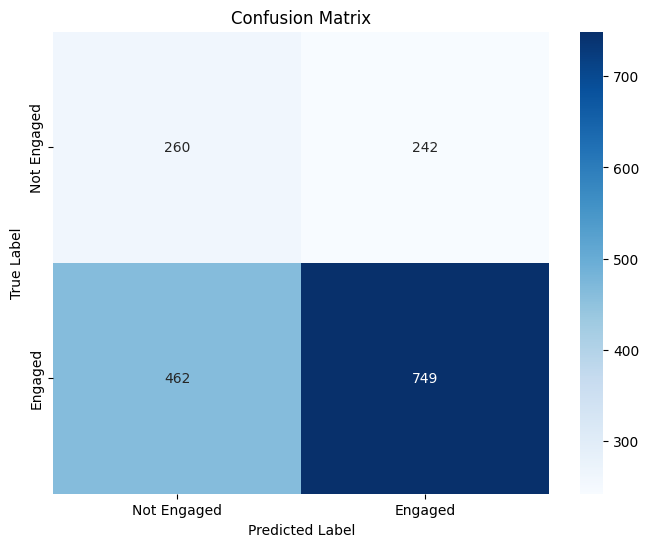

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating detailed performance metrics...")

all_preds = []
all_labels = []

model_eval.eval() # Ensure model is in evaluation mode
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_eval(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Define binary class names for reporting
binary_class_names = ['Not Engaged', 'Engaged']

# 1. Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=binary_class_names))

# 2. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Calculating Precision-Recall Curve for ResNet-18...


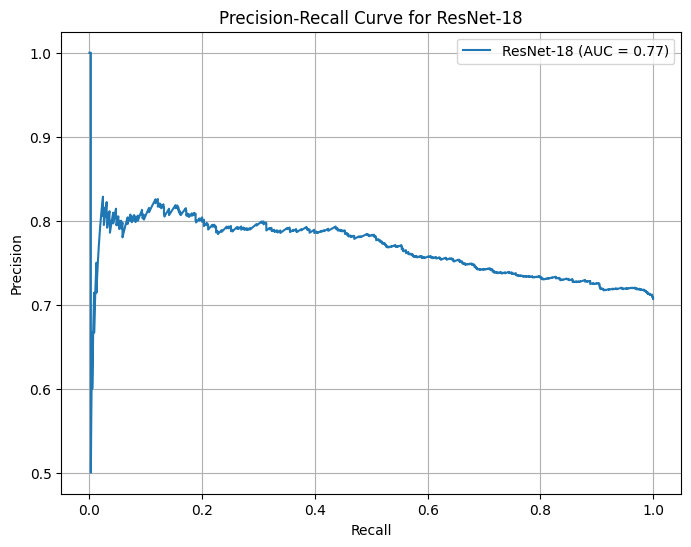

ResNet-18 Precision-Recall AUC: 0.77


In [10]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F

print("Calculating Precision-Recall Curve for ResNet-18...")

# Re-load the model to ensure we have the correct state
model_resnet = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs_resnet = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs_resnet, num_classes)
model_resnet.load_state_dict(torch.load(model_save_path, map_location=device))
model_resnet = model_resnet.to(device)
model_resnet.eval() # Set model to evaluation mode

all_probs_resnet = []
all_labels_pr_resnet = []

with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_resnet(inputs)
        # Get probabilities for the positive class (Engaged, which is index 1)
        probs = F.softmax(outputs, dim=1)[:, 1]
        all_probs_resnet.extend(probs.cpu().numpy())
        all_labels_pr_resnet.extend(labels.cpu().numpy())

# Calculate precision and recall
precision_resnet, recall_resnet, _ = precision_recall_curve(all_labels_pr_resnet, all_probs_resnet)
auc_score_resnet = auc(recall_resnet, precision_resnet)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_resnet, precision_resnet, label=f'ResNet-18 (AUC = {auc_score_resnet:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for ResNet-18')
plt.legend()
plt.grid(True)
plt.show()

print(f"ResNet-18 Precision-Recall AUC: {auc_score_resnet:.2f}")

In [11]:
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, classification_report

# Define the target directory in Google Drive for results
drive_results_dir = os.path.join('/content/drive/MyDrive/DAiSEE_Processed_Faces_Binary', 'results')
os.makedirs(drive_results_dir, exist_ok=True)

# 1. Save the trained model to Google Drive
saved_model_filename = 'best_finetuned_resnet_model.pt'
source_model_path = saved_model_filename
target_model_path = os.path.join(drive_results_dir, saved_model_filename)

if os.path.exists(source_model_path):
    shutil.copy(source_model_path, target_model_path)
    print(f"Trained model '{saved_model_filename}' successfully copied to Drive: {target_model_path}")
else:
    print(f"Warning: Trained model '{saved_model_filename}' not found at {source_model_path}. Skipping save to Drive.")

Trained model 'best_finetuned_resnet_model.pt' successfully copied to Drive: /content/drive/MyDrive/DAiSEE_Processed_Faces_Binary/results/best_finetuned_resnet_model.pt


In [12]:
# 2. Save the Confusion Matrix plot to Google Drive
# Re-generate the confusion matrix plot to save it
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

confusion_matrix_save_path = os.path.join(drive_results_dir, 'confusion_matrix.png')
plt.savefig(confusion_matrix_save_path)
plt.close() # Close the plot to prevent it from being displayed twice
print(f"Confusion Matrix plot saved to Drive: {confusion_matrix_save_path}")

Confusion Matrix plot saved to Drive: /content/drive/MyDrive/DAiSEE_Processed_Faces_Binary/results/confusion_matrix.png


In [13]:
# 3. Save the Precision-Recall Curve plot to Google Drive
# Re-generate the PR curve plot to save it
plt.figure(figsize=(8, 6))
plt.plot(recall_resnet, precision_resnet, label=f'ResNet-18 (AUC = {auc_score_resnet:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for ResNet-18')
plt.legend()
plt.grid(True)

pr_curve_save_path = os.path.join(drive_results_dir, 'precision_recall_curve.png')
plt.savefig(pr_curve_save_path)
plt.close() # Close the plot
print(f"Precision-Recall Curve plot saved to Drive: {pr_curve_save_path}")

Precision-Recall Curve plot saved to Drive: /content/drive/MyDrive/DAiSEE_Processed_Faces_Binary/results/precision_recall_curve.png


All significant generated outputs (trained model weights, confusion matrix plot, and precision-recall curve plot) have been saved to your Google Drive in the `DAiSEE_Processed_Faces_Binary/results` directory. You can find them at: `/content/drive/MyDrive/DAiSEE_Processed_Faces_Binary/results`